# Lending Club Loan Performance & Risk Analysis (2007–2018)

Peer-to-peer lending platforms must carefully balance credit risk management with loan portfolio profitability. Ineffective risk assessment can lead to higher default rates, reduced investor confidence, and lower financial sustainability.

Lending institutions therefore need to better understand how borrower characteristics, loan attributes, and financial behavior influence loan performance and default risk.

Using historical lending data from Lending Club (2007–2018), this project analyzes loan outcomes to uncover patterns in borrower profiles, loan characteristics, and repayment behavior.

The objective is to generate data-driven insights that can help lending companies:

- Identify high-risk borrower profiles

- Understand the relationship between loan characteristics and default rates

- Evaluate the profitability of different loan segments

- Support better credit risk and lending strategy decisions

The analysis uses Python for data cleaning and exploratory analysis, SQL for business queries, and Power BI to create an interactive dashboard for financial insights.

---

## Connecting dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/lending_analysis.csv", low_memory=False)

---

## Data Overview

Prior to any detailed analysis it’s good practice to inspect the raw table.  
In this section we

- report the **shape** (rows × columns).
- review **dtype** distribution.
- compute basic **memory usage** to optimize the dataset.
- have a first look of missing values.

These checks provide a quick snapshot of data quality and help guide the cleaning and exploratory steps that follow.

In [18]:
# Generate insights from df.info()
print("=" * 60)
print("KEY INSIGHTS FROM DATAFRAME STRUCTURE")
print("=" * 60)

# Dataset size
print(f"\n1. DATASET DIMENSIONS:")
print(f"   - Total rows: {df.shape[0]:,}")
print(f"   - Total columns: {df.shape[1]}")

# Data type distribution
print(f"\n2. DATA TYPE DISTRIBUTION:")
dtypes_count = df.dtypes.value_counts()
for dtype, count in dtypes_count.items():
    print(f"   - {dtype}: {count} columns ({count/len(df.columns)*100:.1f}%)")

# Memory usage
memory_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
print(f"\n3. MEMORY USAGE:")
print(f"   - Total: {memory_mb:,.0f} MB ({memory_mb/1024:.1f} GB)")
print(f"   - Per row: {memory_mb*1024*1024/len(df):.2f} bytes")

# Missing values
print(f"\n4. DATA COMPLETENESS:")
null_counts = df.isnull().sum()
cols_with_nulls = (null_counts > 0).sum()
total_nulls = null_counts.sum()
completeness = (1 - (total_nulls / (len(df) * len(df.columns))))*100
print(f"   - Columns with missing values: {cols_with_nulls}")
print(f"   - Total missing values: {total_nulls:,}")
print(f"   - Data completeness: {completeness:.2f}%")

# Top columns with missing values
if cols_with_nulls > 0:
    print(f"\n5. TOP COLUMNS WITH MISSING VALUES:")
    top_nulls = null_counts[null_counts > 0].nlargest(5)
    for col, count in top_nulls.items():
        print(f"   - {col}: {count:,} missing ({count/len(df)*100:.2f}%)")

print("\n" + "=" * 60)

KEY INSIGHTS FROM DATAFRAME STRUCTURE

1. DATASET DIMENSIONS:
   - Total rows: 2,260,701
   - Total columns: 151

2. DATA TYPE DISTRIBUTION:
   - float64: 113 columns (74.8%)
   - str: 38 columns (25.2%)

3. MEMORY USAGE:
   - Total: 3,138 MB (3.1 GB)
   - Per row: 1455.67 bytes

4. DATA COMPLETENESS:
   - Columns with missing values: 150
   - Total missing values: 108,486,252
   - Data completeness: 68.22%

5. TOP COLUMNS WITH MISSING VALUES:
   - member_id: 2,260,701 missing (100.00%)
   - orig_projected_additional_accrued_interest: 2,252,050 missing (99.62%)
   - hardship_type: 2,249,784 missing (99.52%)
   - hardship_reason: 2,249,784 missing (99.52%)
   - hardship_status: 2,249,784 missing (99.52%)



**Dataset Composition**
- **Large Dataset**: 2.26M+ rows with 151 columns provides substantial data for risk analysis
- **Mixed Data Types**: 74.8% numeric columns (113) enable statistical analysis; 25.2% string columns (38) contain categorical/text information for feature extraction

**Data Quality Concerns**
- **Significant Missing Data**: Only 68.22% data completeness indicates substantial gaps that will impact analysis reliability
- **Critical Issue**: `member_id` column is 100% missing, compromising unique record identification
- **High Missingness in Loan Modification Features**: Hardship-related columns (type, reason, status) are 99.5% missing, limiting hardship analysis capability

**Memory & Performance**
- **High Memory Footprint**: 3.1 GB total (~1,456 bytes/row) requires efficient processing and may need optimization for real-time analysis

**Data Preparation Needs**
- **Missing Value Imputation**: 150/151 columns have missing values requiring strategic handling (removal or imputation approach)

## Data Cleaning

This dataset has many columns, some of them are unnecessary or could be left aside, for missing values a good practice is to separate columns in categories, duplicates have to be eliminated due to conflicting and incorrect results, and review the data for last corrections is a very important step to ensure a clean, reliable and secure dataset.

In [50]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

### Selecting columns

After viewing the variables and set loan_status as the target variable the columns to use are:

In [51]:
df_cleaned = df[[
    # Target variable
    "loan_status",

    # Credit profile
    "fico_range_low", 
    "fico_range_high", 
    "grade", 
    "delinq_2yrs", 
    "inq_last_6mths",

    # Debt & Income metrics
    "dti", 
    "annual_inc", 
    "revol_util",

    # Loan specifics
    "loan_amnt", 
    "int_rate", 
    "term", 
    "purpose",
    "issue_d",
    "installment",

    # Credit history
    "earliest_cr_line", 
    "total_acc", 
    "open_acc",
    "mths_since_last_delinq",

    # Performance
    "total_pymnt"
]]

Now check for missing values and duplicates, and data type issues is a crucial step to ensure accuracy and reliability in the analysis.

### Handling missing values

In [52]:
df_cleaned.isnull().sum()

loan_status                    33
fico_range_low                 33
fico_range_high                33
grade                          33
delinq_2yrs                    62
inq_last_6mths                 63
dti                          1744
annual_inc                     37
revol_util                   1835
loan_amnt                      33
int_rate                       33
term                           33
purpose                        33
issue_d                        33
installment                    33
earliest_cr_line               62
total_acc                      62
open_acc                       62
mths_since_last_delinq    1158535
total_pymnt                    33
dtype: int64

In [53]:
# Small missing values
df_cleaned = df_cleaned.dropna(subset=["inq_last_6mths"])

# Medium missing values
df_cleaned["dti"] = df_cleaned["dti"].fillna(df_cleaned["dti"].median())
df_cleaned["revol_util"] = df_cleaned["revol_util"].fillna(df_cleaned["revol_util"].median())

# Very large missing values
df_cleaned["mths_since_last_delinq"] = df_cleaned["mths_since_last_delinq"].fillna(0)

df_cleaned.isnull().sum()

loan_status               0
fico_range_low            0
fico_range_high           0
grade                     0
delinq_2yrs               0
inq_last_6mths            0
dti                       0
annual_inc                0
revol_util                0
loan_amnt                 0
int_rate                  0
term                      0
purpose                   0
issue_d                   0
installment               0
earliest_cr_line          0
total_acc                 0
open_acc                  0
mths_since_last_delinq    0
total_pymnt               0
dtype: int64

### Eliminating duplicates

In [54]:
df_cleaned.duplicated().sum()

np.int64(0)

### Resolving data type issues

1. For **loan status** is better to classify all these segments into two separate statements: "Default" and "No default"

In [55]:
df_cleaned["loan_status"].value_counts()

loan_status
Fully Paid                                             1076750
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1962
Does not meet the credit policy. Status:Charged Off        758
Default                                                     40
Name: count, dtype: int64

In [56]:
# Remove values that are not useful for the analysis
df_cleaned = df_cleaned[df_cleaned["loan_status"] != "Current"]
df_cleaned = df_cleaned[df_cleaned["loan_status"] != "In Grace Period"]
df_cleaned = df_cleaned[~df_cleaned["loan_status"].str.contains("Does not meet")]

# Create a binary target variable
df_cleaned["default"] = df_cleaned["loan_status"].apply(
    lambda x: 1 if x in [
        "Charged Off",
        "Default",
        "Late (31-120 days)",
        "Late (16-30 days)"
    ] else 0
)

# Drop the original target variable
df_cleaned = df_cleaned.drop(columns=["loan_status"])

df_cleaned["default"].value_counts()

default
0    1076750
1     294415
Name: count, dtype: int64

2. **Term** could be in numeric format:

In [57]:
df_cleaned["term"] = df_cleaned["term"].str.strip().str.replace(" months", "").astype(int)

3. **Purpose** Has many categories, one way to handle this is grouping into smaller segments:

In [58]:
df_cleaned["purpose"].value_counts()

purpose
debt_consolidation    795338
credit_card           300119
home_improvement       89273
other                  79791
major_purchase         30102
medical                15899
small_business         15826
car                    14810
moving                  9701
vacation                9252
house                   7483
wedding                 2294
renewable_energy         951
educational              326
Name: count, dtype: int64

In [59]:
purpose_map = {
    # debt refinancing
    "debt_consolidation": "Debt",
    "credit_card": "Debt",

    # Consumer spending
    "major_purchase": "Consumer",
    "car": "Consumer",
    "vacation": "Consumer",
    "moving": "Consumer",
    "wedding": "Consumer",

    # Home-related loans
    "home_improvement": "Home",
    "house": "Home",

    # Business loans
    "small_business": "Business",
    "renewable_energy": "Business",

    # Education and medical
    "medical": "Health/Education",
    "educational": "Health/Education",

    # Other
    "other": "Other"
}

df_cleaned["purpose_group"] = df_cleaned["purpose"].map(purpose_map)

df_cleaned = df_cleaned.drop(columns=["purpose"])

4. **issue_d** and **earliest_cr_line** are date columns, so fix them is the next step:

In [60]:
df_cleaned["issue_d"] = pd.to_datetime(df_cleaned["issue_d"], format="%b-%Y")
df_cleaned["earliest_cr_line"] = pd.to_datetime(df_cleaned["earliest_cr_line"], format="%b-%Y")

5. **FICO score** could be represented in just one column:

In [61]:
df_cleaned["fico_score"] = (df_cleaned["fico_range_low"] + df_cleaned["fico_range_high"]) / 2

df_cleaned = df_cleaned.drop(columns=["fico_range_low", "fico_range_high"])

6. Finally, some columns are float but cannot logically contain decimals:

In [62]:
count_cols = [
    "delinq_2yrs",
    "inq_last_6mths",
    "total_acc",
    "open_acc",
    "mths_since_last_delinq"
]

df_cleaned[count_cols] = df_cleaned[count_cols].astype("int64")

# total_pymnt has many decimals, we can round it to 2 decimals for better readability
df_cleaned["total_pymnt"] = df_cleaned["total_pymnt"].round(2)

Let's take a look of the cleaned dataset:

In [63]:
df_cleaned.head()

,grade,delinq_2yrs,inq_last_6mths,dti,annual_inc,revol_util,loan_amnt,int_rate,term,issue_d,installment,earliest_cr_line,total_acc,open_acc,mths_since_last_delinq,total_pymnt,default,purpose_group,fico_score
0,C,0,1,5.91,55000.0,29.7,3600.0,13.99,36,2015-12-01,123.03,2003-08-01,13,7,30,4421.72,0,Debt,677.0
1,C,1,4,16.06,65000.0,19.2,24700.0,11.99,36,2015-12-01,820.28,1999-12-01,38,22,6,25679.66,0,Business,717.0
2,B,0,0,10.78,63000.0,56.2,20000.0,10.78,60,2015-12-01,432.66,2000-08-01,18,6,0,22705.92,0,Home,697.0
4,F,1,3,25.37,104433.0,64.5,10400.0,22.45,60,2015-12-01,289.91,1998-06-01,35,12,12,11740.50,0,Consumer,697.0
5,C,0,0,10.20,34000.0,68.4,11950.0,13.44,36,2015-12-01,405.18,1987-10-01,6,5,0,13708.95,0,Debt,692.0


## Data summary

Now the dataset is ready to be analyzed! Here's a summary of the cleaning steps completed:

**Data Cleaning Summary:**

1. **Removed irrelevant columns** (e.g., `member_id` with 100% missing values)
2. **Handled missing values** through strategic imputation and removal
3. **Eliminated duplicates** ensuring realistic insights
4.  - **Standardized data types** (converted count columns to integers rounded monetary values)
    - **Created categorical groupings** (consolidated loan purposes into meaningful categories)
    - **Validated data integrity** and prepared for analysis

The cleaned dataset is going to be saved as `data/cleaned_loans.csv` to be ready for exploratory data analysis and modeling.

In [64]:
df_cleaned.to_csv("data/cleaned_loans.csv", index=False)

## Exploratory Data Analysis (EDA)

### Default distribution by purpose group

                    total  defaults  default_rate
purpose_group                                    
Business            16777      5229      0.311677
Health/Education    16225      3788      0.233467
Other               79791     18301      0.229362
Debt              1095457    234854      0.214389
Consumer            66159     13155      0.198839
Home                96756     19088      0.197280


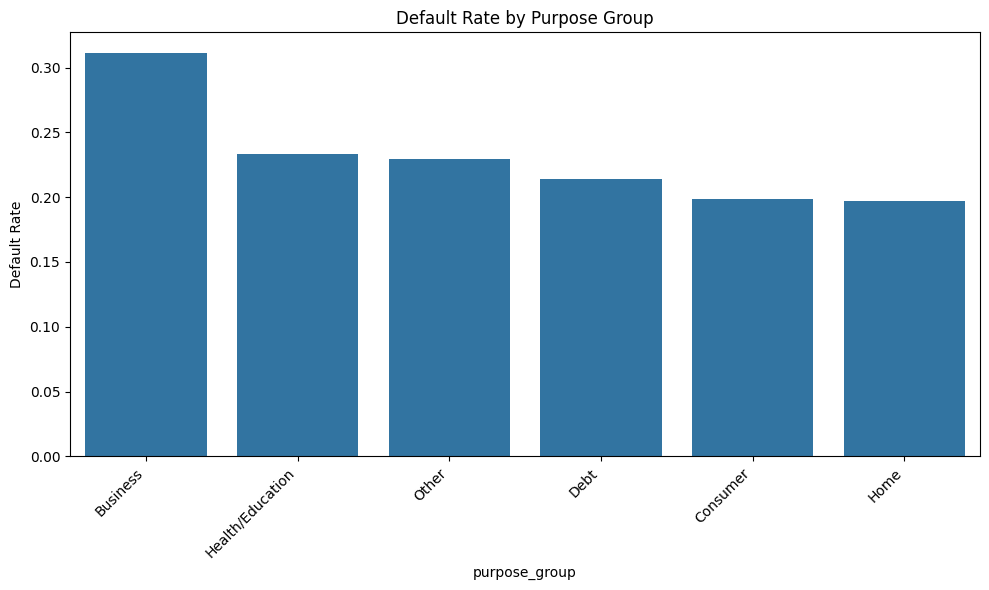

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

purpose_default = (df_cleaned
    .groupby('purpose_group')['default']
    .agg(total='count', defaults='sum')
    .assign(default_rate=lambda x: x['defaults'] / x['total'])
    .sort_values('default_rate', ascending=False)
)

print(purpose_default)

plt.figure(figsize=(10, 6))
sns.barplot(data=purpose_default.reset_index(), x='purpose_group', y='default_rate')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Default Rate')
plt.title('Default Rate by Purpose Group')
plt.tight_layout()
plt.show()

### Default distribution by grade

        total  defaults  default_rate
grade                                
A      236758     15869      0.067026
B      398528     58357      0.146431
C      390724     94687      0.242337
D      206696     66797      0.323165
E       96224     38609      0.401241
F       32828     15261      0.464878
G        9407      4835      0.513979


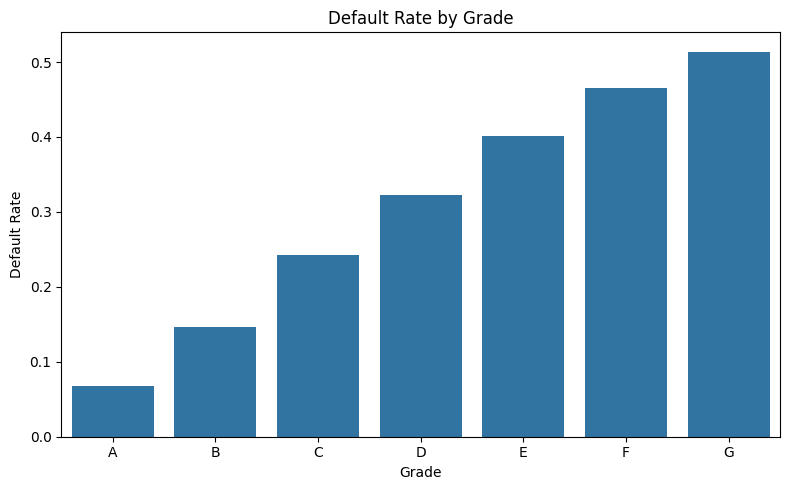

In [30]:
grade_default = (df_cleaned
    .groupby('grade')['default']
    .agg(total='count', defaults='sum')
    .assign(default_rate=lambda x: x['defaults'] / x['total'])
)

print(grade_default)

plt.figure(figsize=(8, 5))
sns.barplot(data=grade_default.reset_index(), x='grade', y='default_rate', order=sorted(df_cleaned['grade'].dropna().unique()))
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')
plt.tight_layout()
plt.show()

### Average loan amount by loan status

Now we can use the clean data into power BI to create meaningful insights